# 09 — من القواعد الخام إلى مرشحات إجراءات أعمال

يحول هذا Notebook القواعد المدققة إلى **candidates requiring controlled validation**. لا يدعي زيادة إيراد أو سببية أو أن العملاء سيشترون Consequent أو أن تغيير الرفوف تدخل مثبت.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

from src.data.paths import PROJECT_ROOT, project_path
from src.recommendation.business_actions import generate_business_actions

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
action_counts = generate_business_actions()
pd.DataFrame([action_counts])

,Promotional test candidate,Monitor for more evidence,Product bundle candidate,Co-display candidate,Cross-sell candidate,Reject from commercial interpretation
0,2281,549,515,58,17,3


## Funnel الأدلة

In [2]:
tiers = pd.read_csv(project_path("outputs", "tables", "rule_evidence_tiers.csv"))
quality = pd.read_csv(project_path("outputs", "tables", "rule_quality_audit.csv"))
final_candidates = pd.read_csv(project_path("outputs", "tables", "final_interpretation_candidates.csv"))
display(tiers)
print(f"Phase 4 candidates: {len(quality):,}; evidence-qualified final candidates: {len(final_candidates):,}")
display(final_candidates[["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "evidence_tier", "quality_flags"]].head(15))

,evidence_tier,rule_count,rule_percentage
0,Tier A,590,17.236342
1,Tier B,2281,66.637453
2,Tier C,549,16.038563
3,Tier D,3,0.087642


Phase 4 candidates: 3,423; evidence-qualified final candidates: 2,871


,rule_key,support_count,confidence,lift,rule_presence_rate,evidence_tier,quality_flags
0,22697 => 22699,700,0.751073,14.063763,1.0,Tier A,reciprocal_rule_exists
1,22698 => 22697,576,0.820513,15.759657,1.0,Tier A,none
2,22698 => 22699,545,0.776353,14.537134,1.0,Tier A,none
3,22698 | 22699 => 22697,492,0.902752,17.339237,1.0,Tier A,none
4,22697 | 22698 => 22699,492,0.854167,15.994181,1.0,Tier A,none
5,21931 | 22386 => 85099B,405,0.801980,7.419249,1.0,Tier A,common_consequent
6,21931 | 22411 => 85099B,384,0.748538,6.924847,1.0,Tier A,common_consequent
7,22578 => 22577,368,0.768267,27.019158,1.0,Tier A,reciprocal_rule_exists
8,22386 | 22411 => 85099B,366,0.806167,7.457986,1.0,Tier A,common_consequent
9,22423 | 22699 => 22697,359,0.790749,15.187979,1.0,Tier A,none


## تفسير Product Network

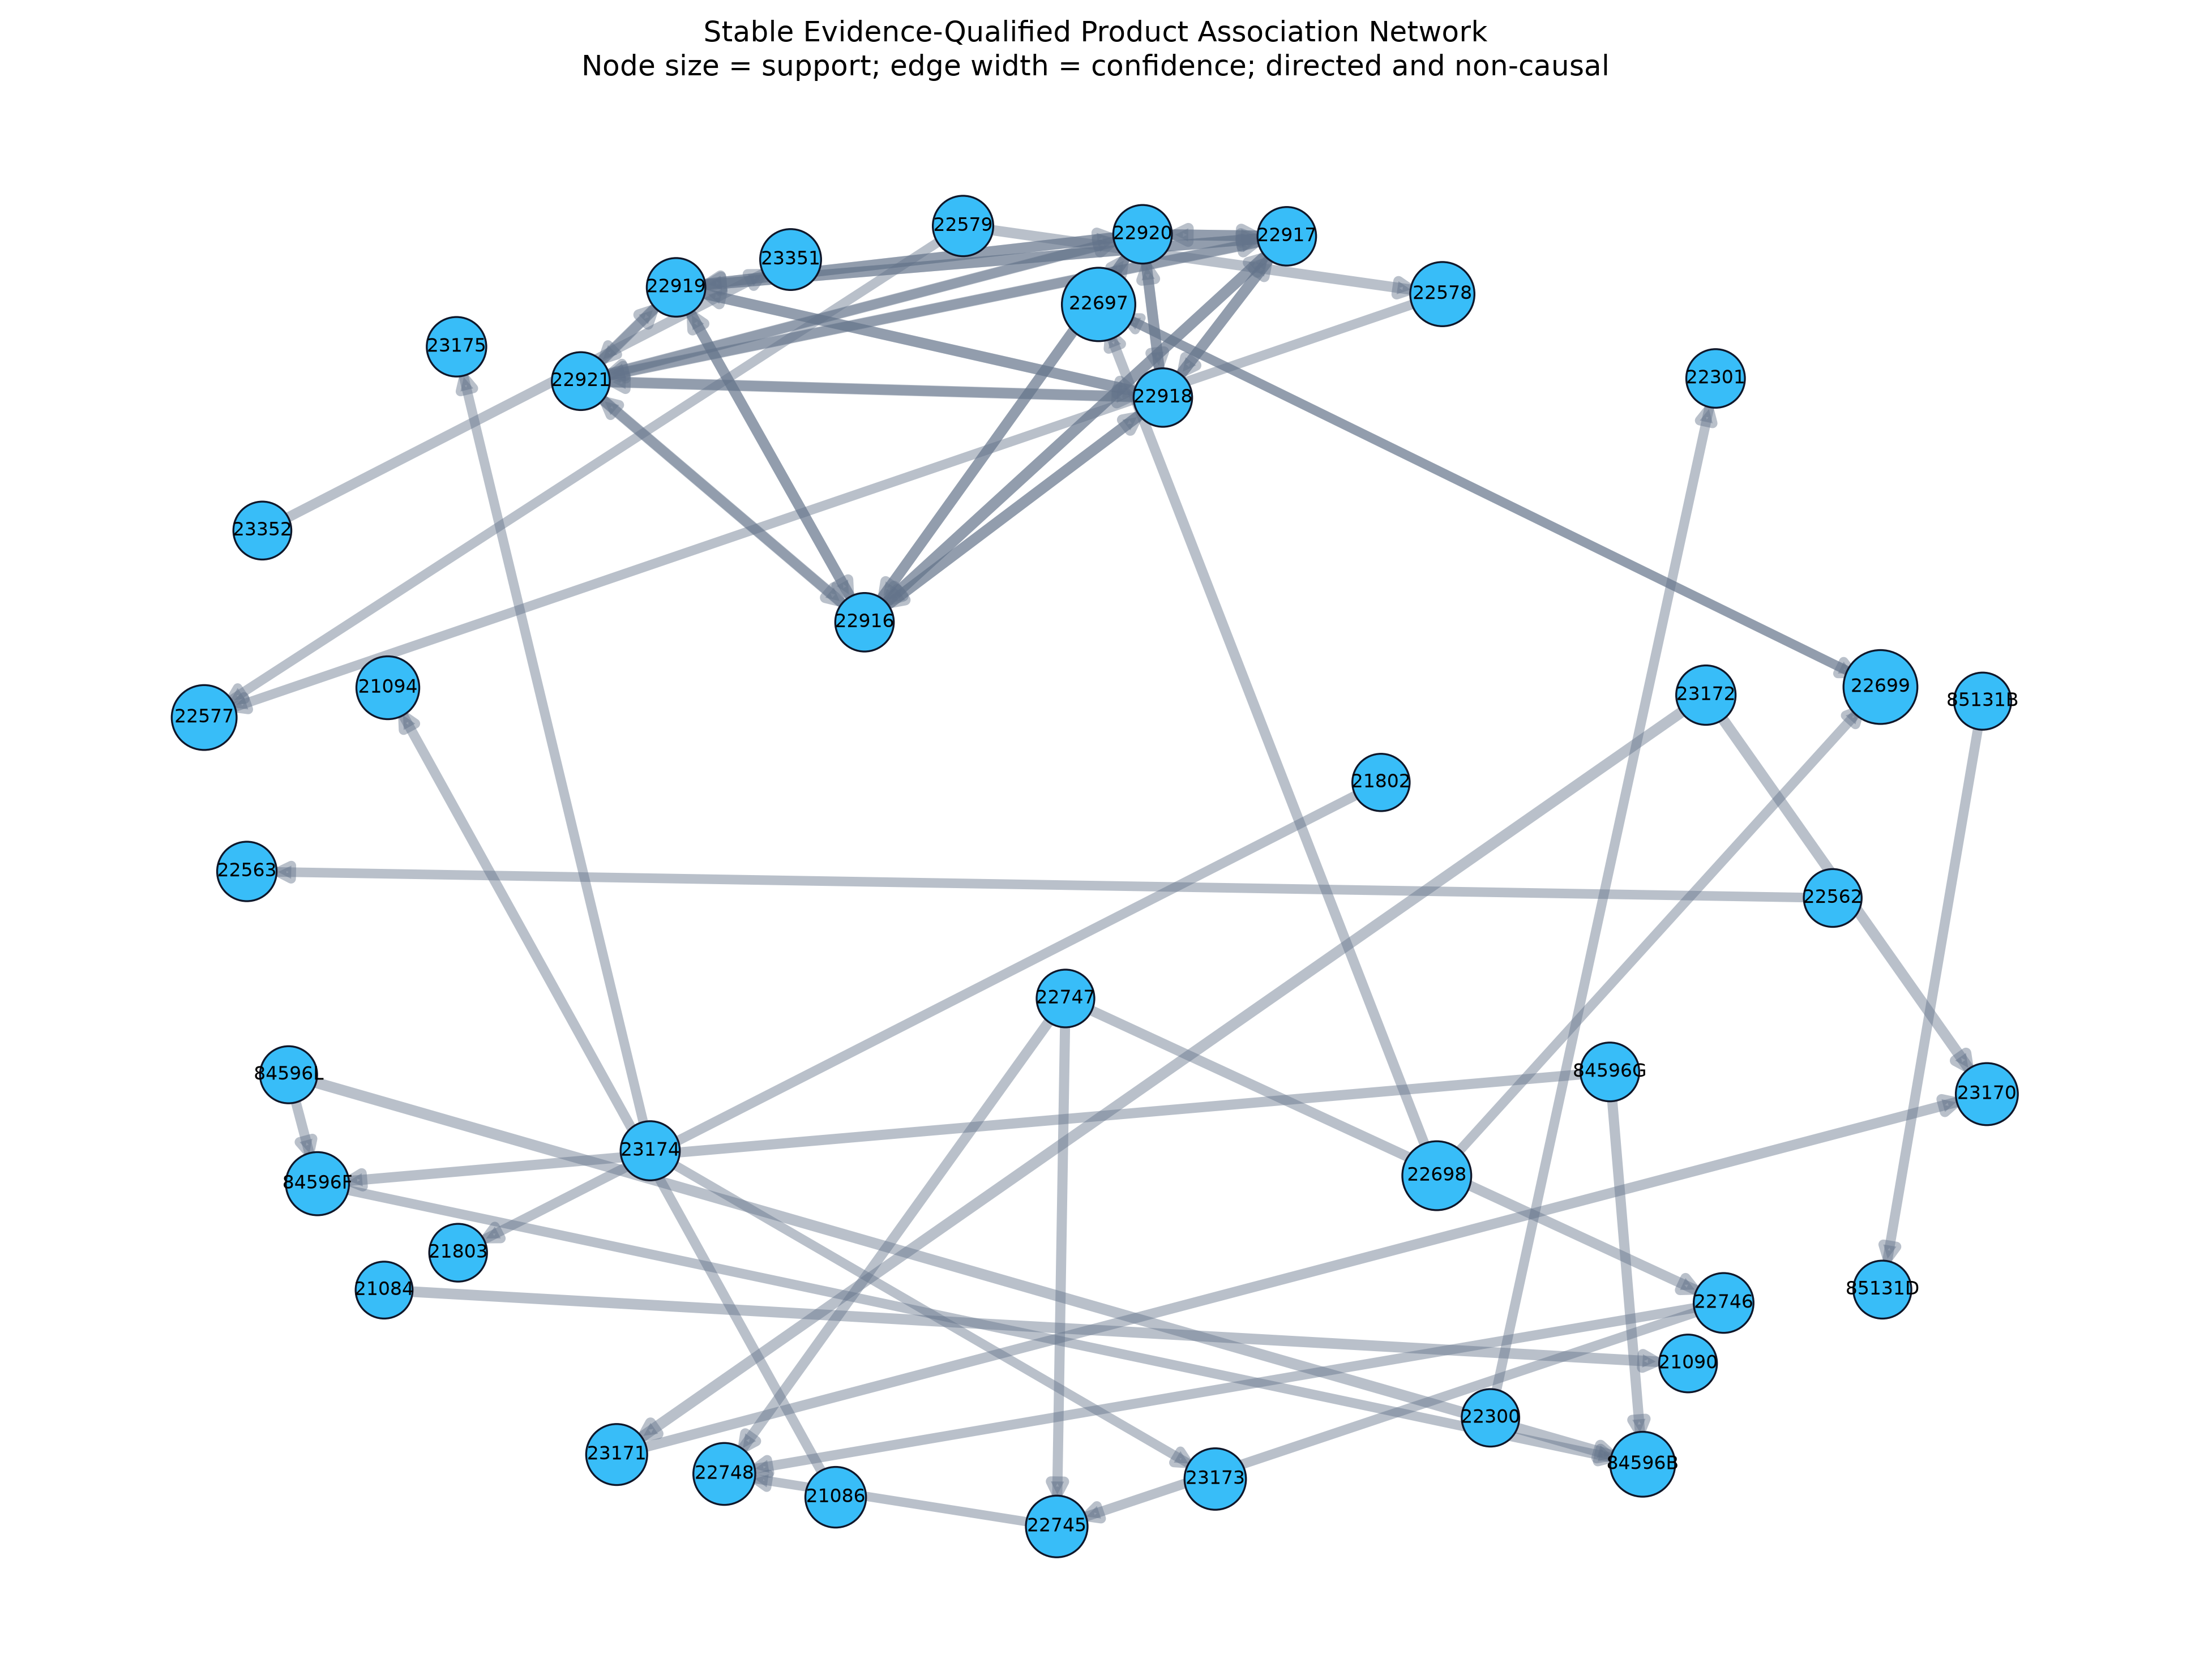

,metric,value
0,node_count,40.0
1,directed_edge_count,60.0
2,weakly_connected_components,14.0
3,largest_component_nodes,6.0
4,maximum_nodes_filter,40.0
5,maximum_edges_filter,60.0
6,minimum_presence_rate,0.8
7,minimum_confidence,0.7
8,minimum_lift,1.2


In [3]:
display(Image(filename=str(project_path("outputs", "figures", "product_network_preview.png")), width=950))
display(pd.read_csv(project_path("outputs", "tables", "product_network_summary.csv")))

الشبكة تلخص عينة مقروءة من العلاقات المستقرة one-to-one. الدرجة أو المكون لا يعنيان أهمية مالية أو سبباً للشراء؛ هما وصف لبنية القواعد المختارة.

## منهج Business Action Generator

In [4]:
actions = pd.read_csv(project_path("outputs", "tables", "business_action_candidates.csv"))
action_summary = pd.read_csv(project_path("outputs", "tables", "business_action_summary.csv"))
display(action_summary)

,action_category,rule_count,rule_percentage
0,Promotional test candidate,2281,66.637453
1,Monitor for more evidence,549,16.038563
2,Product bundle candidate,515,15.045282
3,Co-display candidate,58,1.694420
4,Cross-sell candidate,17,0.496640
5,Reject from commercial interpretation,3,0.087642


## Bundle وCross-sell وCo-display candidates

In [5]:
for category in ["Product bundle candidate", "Cross-sell candidate", "Co-display candidate"]:
    print(category)
    display(actions.loc[actions.action_category.eq(category), ["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "evidence_tier", "suggested_validation_step"]].head(8))

Product bundle candidate


,rule_key,support_count,confidence,lift,rule_presence_rate,evidence_tier,suggested_validation_step
624,22697 | 22698 => 22699,492,0.854167,15.994181,1.0,Tier A,"Review product compatibility, then run a contr..."
625,22698 | 22699 => 22697,492,0.902752,17.339237,1.0,Tier A,"Review product compatibility, then run a contr..."
626,21931 | 22386 => 85099B,405,0.801980,7.419249,1.0,Tier A,"Review product compatibility, then run a contr..."
627,21931 | 22411 => 85099B,384,0.748538,6.924847,1.0,Tier A,"Review product compatibility, then run a contr..."
628,22386 | 22411 => 85099B,366,0.806167,7.457986,1.0,Tier A,"Review product compatibility, then run a contr..."
629,22423 | 22699 => 22697,359,0.790749,15.187979,1.0,Tier A,"Review product compatibility, then run a contr..."
630,20723 | 22355 => 20724,322,0.819338,16.242500,1.0,Tier A,"Review product compatibility, then run a contr..."
631,22386 | 85099C => 85099B,318,0.781327,7.228181,1.0,Tier A,"Review product compatibility, then run a contr..."


Cross-sell candidate


,rule_key,support_count,confidence,lift,rule_presence_rate,evidence_tier,suggested_validation_step
58,22920 => 22921,177,0.762931,67.276987,1.0,Tier A,Test a limited non-personalized cross-sell tre...
59,22921 => 22920,177,0.871921,67.276987,1.0,Tier A,Test a limited non-personalized cross-sell tre...
60,23352 => 23351,167,0.814634,43.923994,1.0,Tier A,Test a limited non-personalized cross-sell tre...
61,22747 => 22748,164,0.841026,40.147200,1.0,Tier A,Test a limited non-personalized cross-sell tre...
62,22747 => 22746,162,0.830769,52.549823,1.0,Tier A,Test a limited non-personalized cross-sell tre...
63,22747 => 22745,161,0.825641,40.603846,1.0,Tier A,Test a limited non-personalized cross-sell tre...
64,21902 => 21901,158,0.759615,44.437500,1.0,Tier A,Test a limited non-personalized cross-sell tre...
65,22562 => 22563,154,0.766169,50.985851,1.0,Tier A,Test a limited non-personalized cross-sell tre...


Co-display candidate


,rule_key,support_count,confidence,lift,rule_presence_rate,evidence_tier,suggested_validation_step
0,22697 => 22699,700,0.751073,14.063763,1.0,Tier A,Use a controlled merchandising experiment befo...
1,22698 => 22697,576,0.820513,15.759657,1.0,Tier A,Use a controlled merchandising experiment befo...
2,22698 => 22699,545,0.776353,14.537134,1.0,Tier A,Use a controlled merchandising experiment befo...
3,22578 => 22577,368,0.768267,27.019158,1.0,Tier A,Use a controlled merchandising experiment befo...
4,84596F => 84596B,335,0.779070,27.345349,1.0,Tier A,Use a controlled merchandising experiment befo...
5,23171 => 23170,281,0.836310,39.293377,1.0,Tier A,Use a controlled merchandising experiment befo...
6,22745 => 22748,265,0.728022,34.752857,1.0,Tier A,Use a controlled merchandising experiment befo...
7,22579 => 22578,263,0.848387,31.705590,1.0,Tier A,Use a controlled merchandising experiment befo...


## مرشحون للمراقبة وحالات مرفوضة

In [6]:
more = pd.read_csv(project_path("outputs", "tables", "rules_requiring_more_evidence.csv"))
display(more.loc[more.action_category.eq("Monitor for more evidence")].head(8))
display(more.loc[more.action_category.eq("Reject from commercial interpretation")].head(8))

,rule_key,action_category,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,support,support_count,confidence,lift,rule_presence_rate,stability_category,evidence_tier,quality_flags,action_reason,limitation,suggested_validation_step
0,22423 | 22697 => 22699,Monitor for more evidence,"[""22423"", ""22697""]","[""22423 — REGENCY CAKESTAND 3 TIER"", ""22697 — ...","[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]",0.020055,359,0.790749,14.806690,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
1,22423 | 22698 => 22697,Monitor for more evidence,"[""22423"", ""22698""]","[""22423 — REGENCY CAKESTAND 3 TIER"", ""22698 — ...","[""22697""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER""]",0.016871,302,0.867816,16.668214,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
2,23170 | 23172 => 23171,Monitor for more evidence,"[""23170"", ""23172""]","[""23170 — REGENCY TEA PLATE ROSES"", ""23172 — R...","[""23171""]","[""23171 — REGENCY TEA PLATE GREEN""]",0.012457,223,0.944915,50.342048,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
3,23171 | 23172 => 23170,Monitor for more evidence,"[""23171"", ""23172""]","[""23171 — REGENCY TEA PLATE GREEN"", ""23172 — R...","[""23170""]","[""23170 — REGENCY TEA PLATE ROSES""]",0.012457,223,0.925311,43.475055,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
4,22916 | 22917 => 22918,Monitor for more evidence,"[""22916"", ""22917""]","[""22916 — HERB MARKER THYME"", ""22917 — HERB MA...","[""22918""]","[""22918 — HERB MARKER PARSLEY""]",0.011005,197,0.920561,72.276131,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
5,22916 | 22918 => 22917,Monitor for more evidence,"[""22916"", ""22918""]","[""22916 — HERB MARKER THYME"", ""22918 — HERB MA...","[""22917""]","[""22917 — HERB MARKER ROSEMARY""]",0.011005,197,0.951691,73.749859,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
6,22917 | 22918 => 22916,Monitor for more evidence,"[""22917"", ""22918""]","[""22917 — HERB MARKER ROSEMARY"", ""22918 — HERB...","[""22916""]","[""22916 — HERB MARKER THYME""]",0.011005,197,0.951691,74.070510,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...
7,22697 | 22960 => 22699,Monitor for more evidence,"[""22697"", ""22960""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER"", ""2...","[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]",0.010893,195,0.799180,14.964568,1.0,Very stable,Tier C,none,Tier C; Very stable; presence=1.00; support co...,"Observed association only; no causal, revenue,...",Monitor new transactions and repeat stability ...


,rule_key,action_category,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,support,support_count,confidence,lift,rule_presence_rate,stability_category,evidence_tier,quality_flags,action_reason,limitation,suggested_validation_step
549,23300 | 23344 => 23301,Reject from commercial interpretation,"[""23300"", ""23344""]","[""23300 — GARDENERS KNEELING PAD CUP OF TEA"", ...","[""23301""]","[""23301 — GARDENERS KNEELING PAD KEEP CALM""]",0.005028,90,0.731707,14.586072,0.15,Unstable,Tier D,near_support_floor | high_lift_low_count | wea...,Tier D; Unstable; presence=0.15; support count...,"Observed association only; no causal, revenue,...",Do not operationalize; retain only for audit.
550,22697 | 85131D => 85131B,Reject from commercial interpretation,"[""22697"", ""85131D""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER"", ""8...","[""85131B""]","[""85131B — BEADED CRYSTAL HEART GREEN ON STICK""]",0.005139,92,0.702290,73.091248,0.10,Unstable,Tier D,near_support_floor | high_lift_low_count | wea...,Tier D; Unstable; presence=0.10; support count...,"Observed association only; no causal, revenue,...",Do not operationalize; retain only for audit.
551,22446 => 22961,Reject from commercial interpretation,"[""22446""]","[""22446 — PIN CUSHION BABUSHKA PINK""]","[""22961""]","[""22961 — JAM MAKING SET PRINTED""]",0.005028,90,0.725806,12.889545,0.10,Unstable,Tier D,near_support_floor | high_lift_low_count | wea...,Tier D; Unstable; presence=0.10; support count...,"Observed association only; no causal, revenue,...",Do not operationalize; retain only for audit.


## حدود الاستدلال والتحقق الواقعي

كل إجراء يحفظ `rule_key` والمقاييس والاستقرار والقيد وخطوة التحقق. الأساليب المناسبة لاحقاً تشمل A/B tests مضبوطة، holdout زمني، مراجعة توافق المنتجات، قياس أثر مسبق التعريف، ومراقبة الآثار الجانبية. لا توجد نتائج مالية مقاسة في المشروع.

## استعداد Phase 6

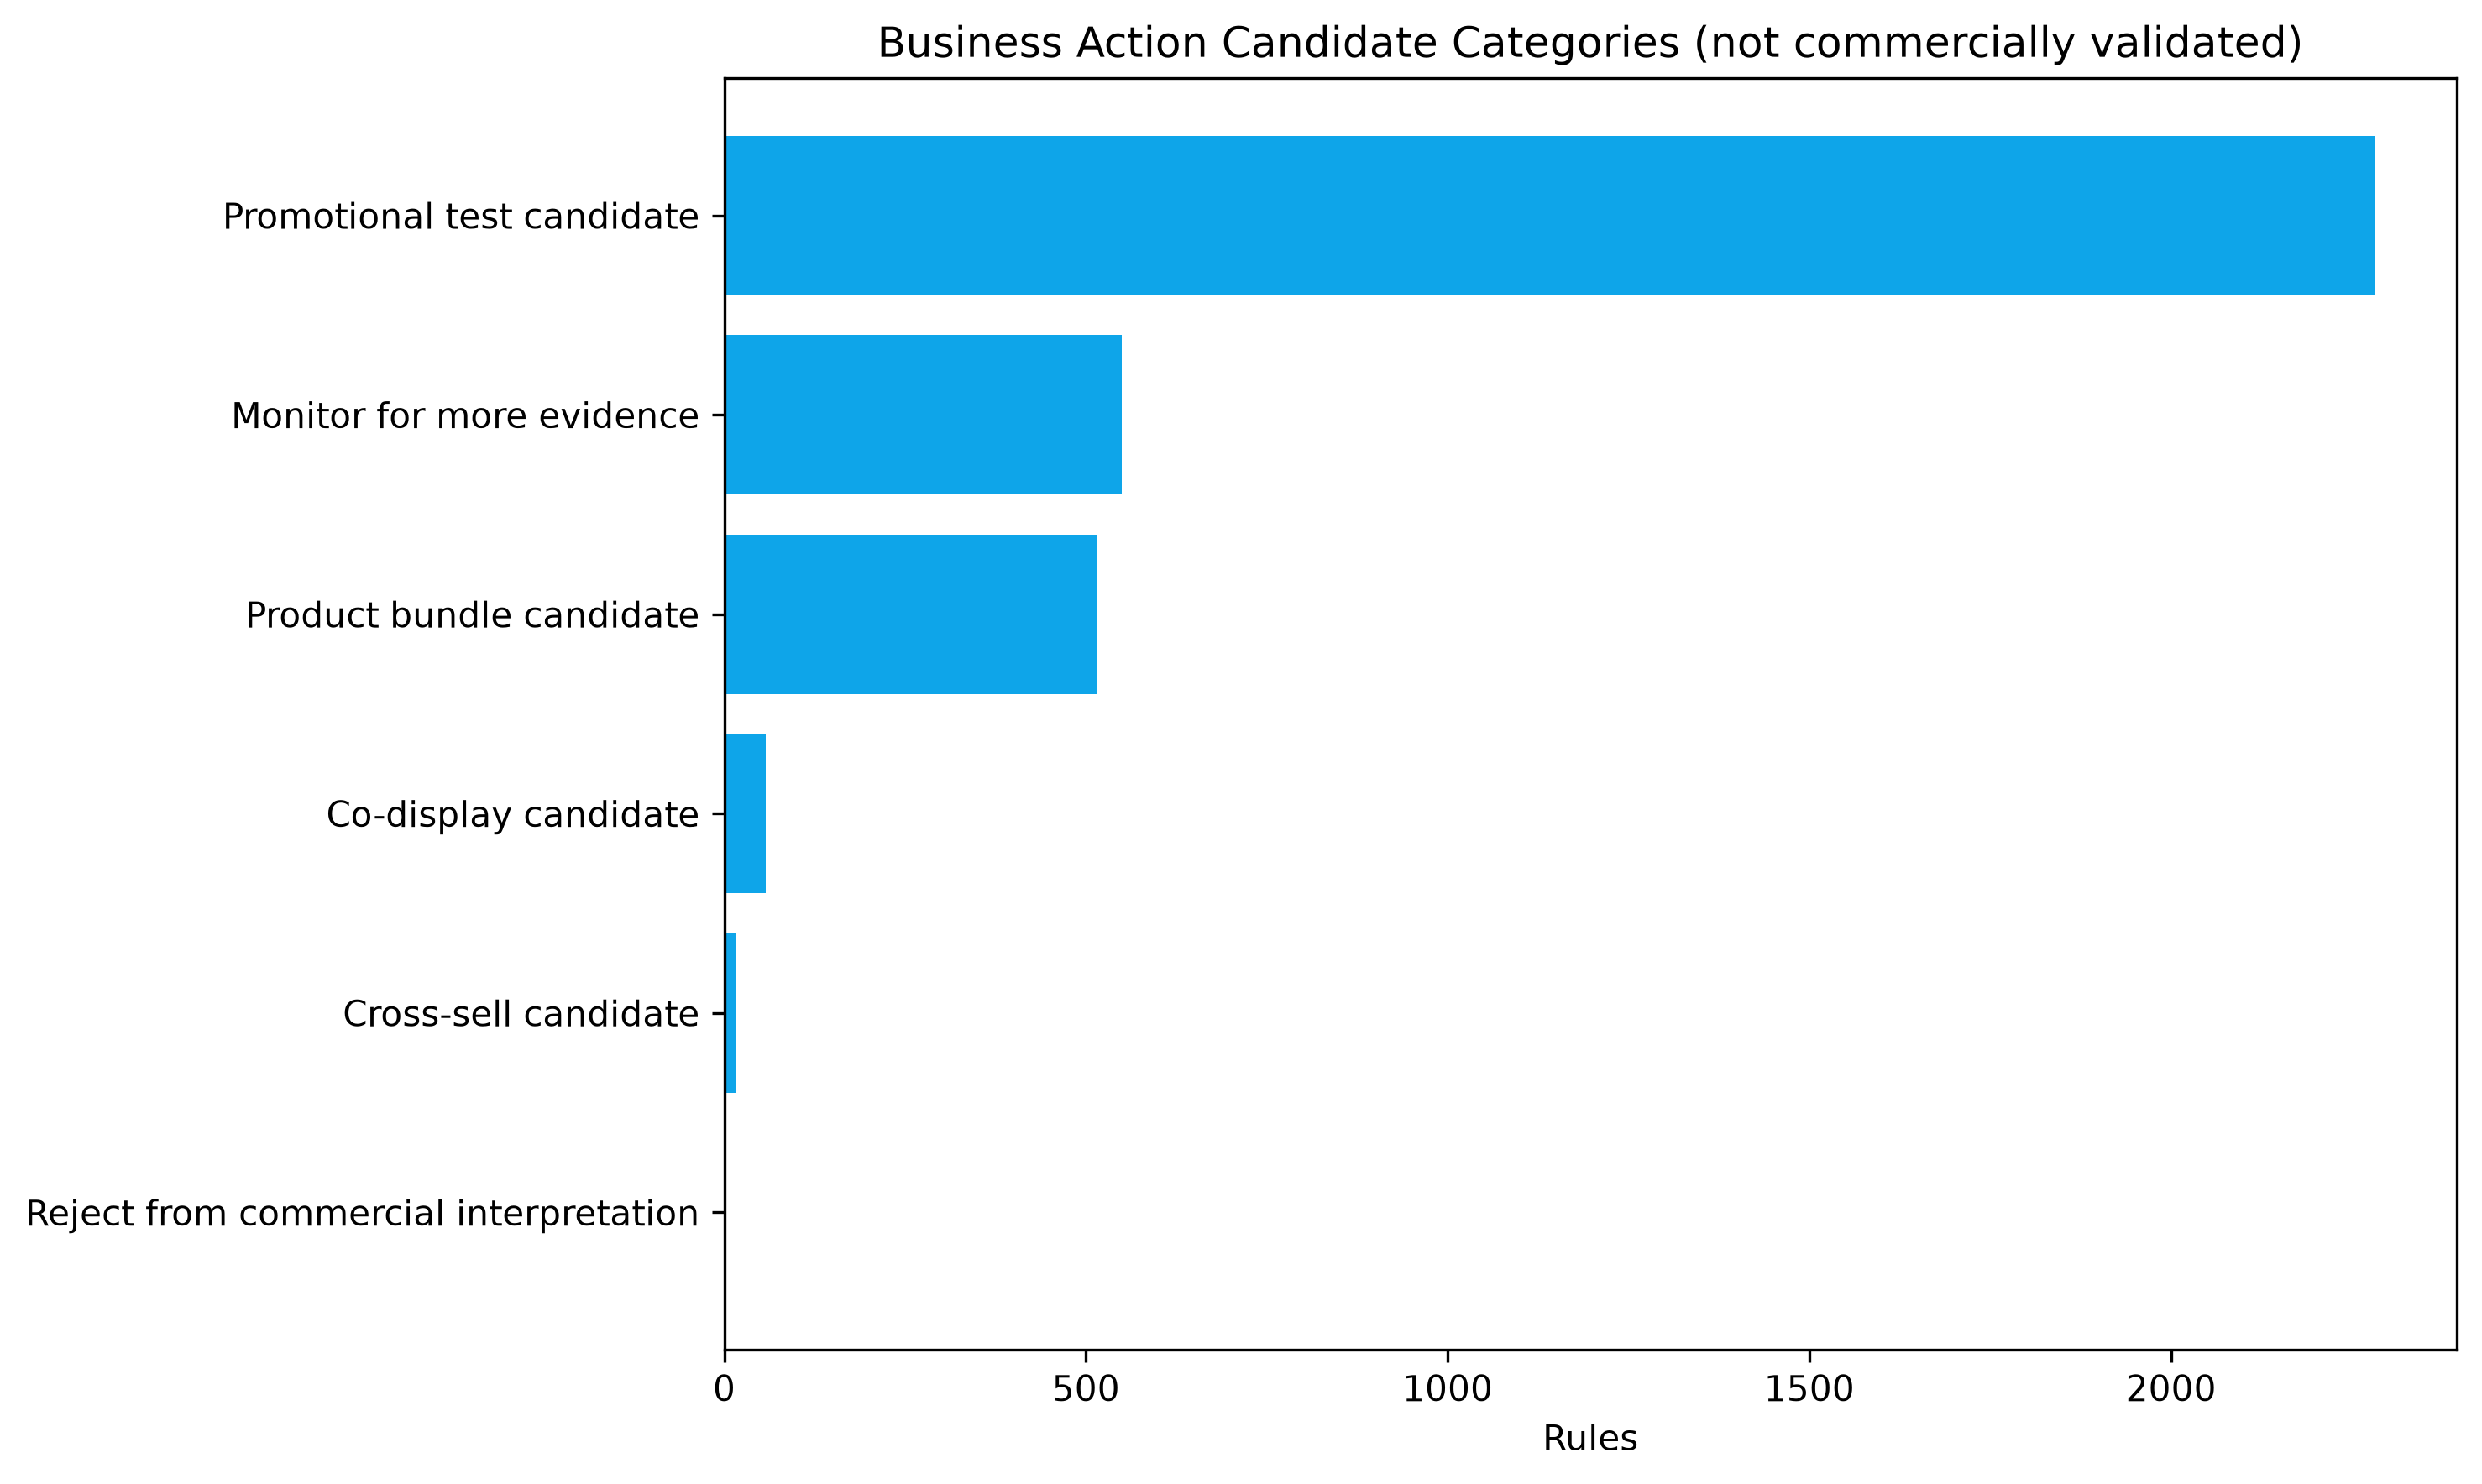

Prepared for later WEKA execution and Python-versus-WEKA audit. WEKA has not been run.


In [7]:
display(Image(filename=str(project_path("outputs", "figures", "business_action_category_distribution.png")), width=900))
print("Prepared for later WEKA execution and Python-versus-WEKA audit. WEKA has not been run.")